# Healthcare Risk Prediction: Machine Learning vs Neural Networks

### Assignment: Diabetes Risk Prediction

**Objective:**  
To predict diabetes risk using patient health indicators and to compare the performance of a traditional Machine Learning model (Logistic Regression) with a Neural Network model.

**Dataset:** healthcare_dataset.csv  
**Target Variable:** diabetes (0 = No Diabetes, 1 = Diabetes)

## 1. Data Understanding & Exploration
In this section, we load the dataset, examine its structure, perform basic statistical analysis, and explore relationships between health indicators (features) and diabetes.

In [167]:
import pandas as pd

df = pd.read_csv('healthcare_dataset.csv')
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [168]:
# Dataset Structure - Getting the number of rows and columns
df.shape

(6000, 7)

In [169]:
# Dataset Structure - Getting the details of all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 non-null   float64
 4   smoker                   6000 non-null   int64  
 5   blood_pressure           6000 non-null   float64
 6   diabetes                 6000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 328.3 KB


In [170]:
# Dataset Structure - Checking for the presence of any null values
df.isnull().sum()

,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


In [171]:
# Statistical Summary of the dataset
df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


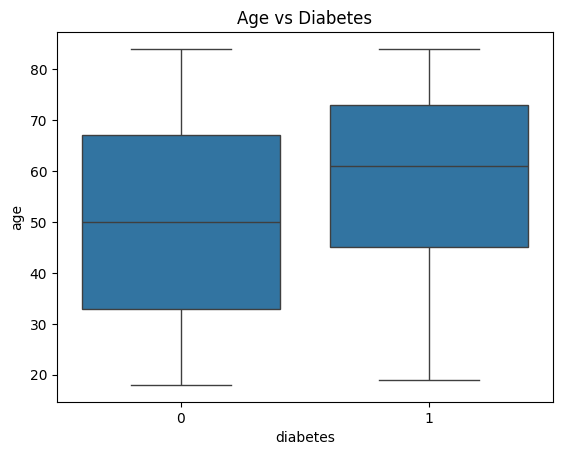

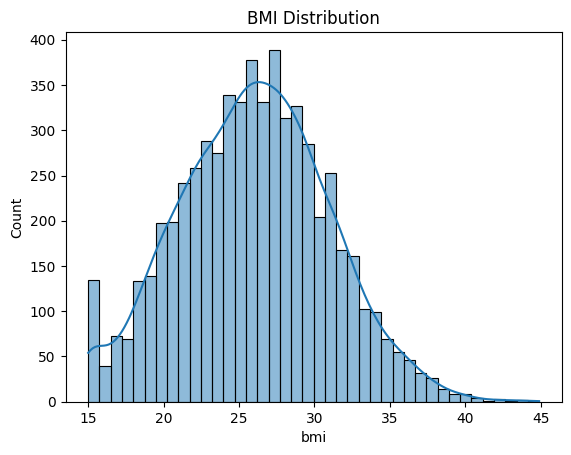

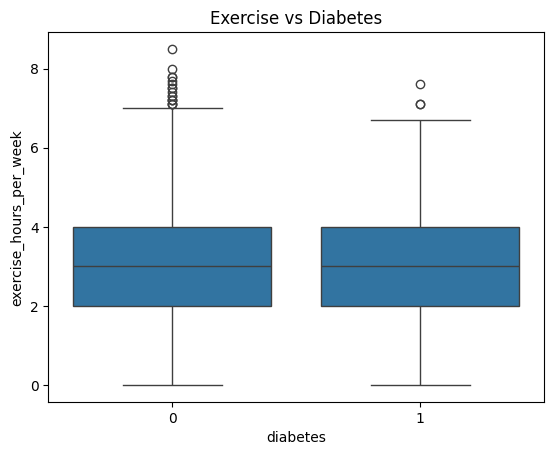

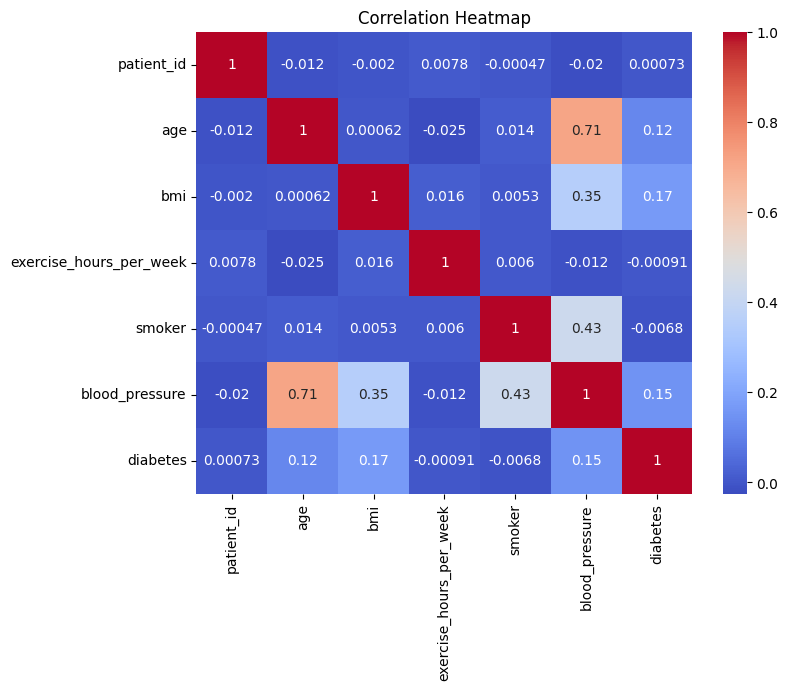

In [172]:
# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Age vs Diabetes
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age vs Diabetes')
plt.show()

# BMI Distribution
sns.histplot(df['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()

# Exercise vs Diabetes
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title('Exercise vs Diabetes')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Key Observations (from EDA)

- Age distributions show some variation between diabetic and non-diabetic patients.
- Higher BMI values appear more frequently among diabetic patients.
- Exercise hours show noticeable differences across the two classes.
- The correlation heatmap highlights relationships between numeric features and diabetes, though no single feature strongly separates the classes.

## 2. Machine Learning Model: Logistic Regression

Logistic Regression is used as a baseline classification model due to its simplicity and interpretability.


### Data Preprocessing
We split the data into training and testing sets to evaluate generalization. Feature scaling is applied because Logistic Regression and Neural Networks perform better when numerical features are standardized.

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['patient_id', 'diabetes'], axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [174]:
# Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [175]:
# Evaluation of the Logistic Regression Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_acc = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy (full): {lr_acc}")
print(f"Logistic Regression Accuracy (rounded): {lr_acc:.4f}\n")
print("Confusion Matrix (Logistic Regression):")
print(cm_lr)
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy (full): 0.9091666666666667
Logistic Regression Accuracy (rounded): 0.9092

Confusion Matrix (Logistic Regression):
[[1091    0]
 [ 109    0]]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Logistic Regression Results

The confusion matrix follows the format [[TN, FP], [FN, TP]]. In this case, the model predicts only the non-diabetic class, resulting in a high number of true negatives but zero true positives. (0 = No Diabetes, 1 = Diabetes)

- The model achieves an overall accuracy of approximately 91%, primarily due to the dominance of the non-diabetic class in the dataset.
- The confusion matrix shows that all samples are predicted as non-diabetic.
- As a result, the model has zero recall and precision for the diabetic class.
- This demonstrates the effect of class imbalance and highlights the limitation of accuracy as a standalone evaluation metric in healthcare problems.

## 3. Neural Network Model

A Neural Network is implemented to capture nonlinear relationships between features.

In [176]:
# Build the Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [177]:
# Train the Neural Network
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8909 - loss: 0.4085 - val_accuracy: 0.9062 - val_loss: 0.3197
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.3029 - val_accuracy: 0.9062 - val_loss: 0.2966
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.2894 - val_accuracy: 0.9062 - val_loss: 0.2908
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.2848 - val_accuracy: 0.9062 - val_loss: 0.2882
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9107 - loss: 0.2834 - val_accuracy: 0.9062 - val_loss: 0.2874
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9107 - loss: 0.2818 - val_accuracy: 0.9062 - val_loss: 0.2876
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9107 - loss: 0.2810 - val_accuracy: 0.9062 - val_loss: 0.2875
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9107 - loss: 0.2805 - val_accuracy: 0.

In [178]:
# Evaluate the Neural Network
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test)
print(f"Neural Network Accuracy (full): {test_accuracy}")
print(f"Neural Network Accuracy (rounded): {test_accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9092 - loss: 0.2797
Neural Network Accuracy (full): 0.909166693687439
Neural Network Accuracy (rounded): 0.9092


In [179]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_nn_prob = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

print("Confusion Matrix (Neural Network):")
print(confusion_matrix(y_test, y_pred_nn))

print("\nClassification Report (Neural Network):")
print(classification_report(y_test, y_pred_nn))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix (Neural Network):
[[1091    0]
 [ 109    0]]

Classification Report (Neural Network):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


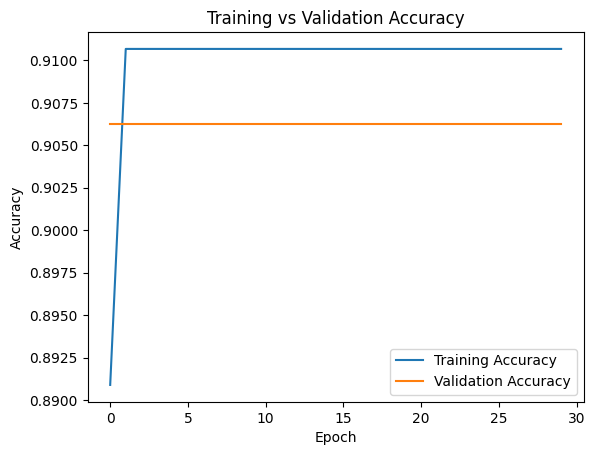

In [180]:
# Training vs Validation Accuracy Curve
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

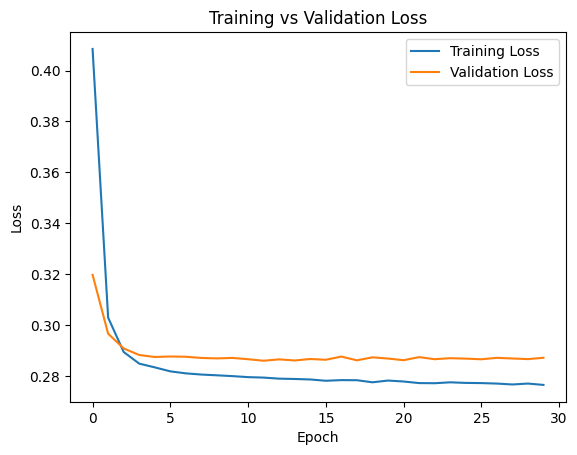

In [181]:
# Training vs Validation Loss Curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

### Neural Network Architecture
- Input Layer: Receives scaled patient health features
- Hidden Layers: Learn complex nonlinear patterns
- Output Layer: Sigmoid activation for binary classification

### Neural Network Results

The confusion matrix follows the format [[TN, FP], [FN, TP]]. In this case, the model predicts only the non-diabetic class, resulting in a high number of true negatives but zero true positives. (0 = No Diabetes, 1 = Diabetes)

- The Neural Network achieves a similar accuracy to Logistic Regression.
- However, the confusion matrix and classification report indicate that the model predicts only the majority class (non-diabetic).
- Despite higher model complexity, the Neural Network does not successfully identify diabetic patients.
- This suggests that class imbalance significantly impacts model performance, regardless of model complexity.

## 4. Model Comparison & Analysis

| Aspect | Logistic Regression | Neural Network |
|---|---|---|
| Accuracy | ~91% | ~91% |
| Diabetes Detection (Recall for Class 1) | 0.00 | 0.00 |
| Interpretability | High | Low |
| Sensitivity to Class Imbalance | High | High |

### Summary
- Both models achieve high accuracy by predicting only the majority class (non-diabetic).
- Neither model successfully identifies diabetic patients, as shown by zero recall for the positive class.
- Both confusion matrices follow the standard [[TN, FP], [FN, TP]] format and show that neither model produces true positive predictions for diabetic patients.
- This highlights the importance of using evaluation metrics beyond accuracy, especially in healthcare applications.
- Addressing class imbalance would be necessary to improve diabetes detection.

### Limitations and Future Improvements
- The dataset is highly imbalanced, with significantly fewer diabetic cases.
- Accuracy alone is not sufficient for evaluating healthcare classification models.
- Future work could include techniques such as class weighting, resampling, or threshold tuning to improve recall for diabetic patients.